# Results — replicate (rep) positions

Collects allele-frequency results produced by the refactored pipeline  
(random positions registered in `data/positions_registry.tsv`, folder names `rep1`, `rep2`, …).

**Path structure** (no redundant `DEL/` level):
```
results/del/{rep_id}/var/cov{cov}_err{err}/{size}/n{n}/f{freq}/k{k}/
```

**Repeat score** is read directly from the registry — no FASTA loading required.

In [1]:
import re
import csv
from pathlib import Path
import numpy as np
import pandas as pd

RESULTS_DIR  = Path('/Users/tatiana/Documents_new/visor_freqk/results')
REGISTRY     = Path('/Users/tatiana/Documents_new/visor_freqk/data/positions_registry.tsv')

RESULTS_DIR  = Path('../results')
REGISTRY     = Path('../data/positions_registry.tsv')

# ── Discover allele-frequency files for rep-style positions ───────────────────
# New path (9 parts relative to RESULTS_DIR):
#   del / rep<N> / var / cov<X>_err<E> / <size> / n<N> / f<F> / k<K> / file
#    0      1      2         3              4       5     6     7       8
#
# Filter: p[1] starts with 'rep'  (excludes old pos10mb-style results)

all_af = sorted(RESULTS_DIR.rglob('*.allele_frequencies.k*.tsv'))

rep_files = [
    f for f in all_af
    if (
        len(f.relative_to(RESULTS_DIR).parts) == 9
        and f.relative_to(RESULTS_DIR).parts[1].startswith('rep')
        and f.relative_to(RESULTS_DIR).parts[2] == 'var'
    )
]

print(f"Total .tsv files found : {len(all_af)}")
print(f"Rep-style (loaded)     : {len(rep_files)}")
print()

# Preview
print(f"{'sv':4s}  {'rep':6s}  {'cov/err':14s}  {'size':5s}  {'n':5s}  {'freq':4s}  {'k':4s}")
print('-' * 60)
for f in rep_files[:20]:
    p = f.relative_to(RESULTS_DIR).parts
    print(f"{p[0]:4s}  {p[1]:6s}  {p[3]:14s}  {p[4]:5s}  {p[5]:5s}  {p[6]:4s}  {p[7]:4s}")
if len(rep_files) > 20:
    print(f"... and {len(rep_files)-20} more")

KeyboardInterrupt: 

In [ ]:
# ── Parse files into rows (freqk + vg_giraffe) ─────────────────────────────────
rows = []

for f in rep_files:
    p = f.relative_to(RESULTS_DIR).parts
    # p[0]=sv_root  p[1]=rep_id  p[2]='var'  p[3]=cov_err
    # p[4]=size     p[5]=n_lbl   p[6]=freq_lbl  p[7]=k_lbl  p[8]=filename

    sv_root   = p[0]                       # 'del'
    rep_id    = p[1]                       # 'rep1', 'rep2', …
    cov_err   = p[3]                       # 'cov10_err001'
    size      = p[4]                       # '100bp', '1kb', …
    n_lbl     = p[5]                       # 'n231'
    freq_lbl  = p[6]                       # 'f90'
    k_lbl     = p[7]                       # 'k31'
    filename  = p[8]

    # Distinguish freqk vs vg giraffe benchmark by filename
    method = 'vg_giraffe' if '.vg_giraffe.' in filename else 'freqk'

    sv_type = sv_root.upper()              # 'DEL'
    cov_part, err_part = cov_err.split('_')
    coverage   = int(cov_part.replace('cov', ''))
    err_str    = err_part.replace('err', '')
    error_rate = 0.0 if err_str == '0' else float('0.' + err_str)
    n_samples    = int(n_lbl.replace('n', ''))
    freq_nominal = int(freq_lbl.replace('f', '')) / 100.0
    k            = int(k_lbl.replace('k', ''))

    # AF values — single line 'af_ref|af_alt', or 'NA|NA' if the tool could
    # not call the variant (e.g. vg pack found no read support).
    text = f.read_text().strip()
    if text == 'NA|NA' or text == '':
        af_ref, af_alt = float('nan'), float('nan')
    else:
        parts  = text.split('|')
        af_ref = float(parts[0])
        af_alt = float(parts[1]) if len(parts) > 1 else float('nan')

    rows.append({
        'sv_root'     : sv_root,
        'sv_type'     : sv_type,
        'rep_id'      : rep_id,
        'method'      : method,
        'cov_err'     : cov_err,
        'coverage'    : coverage,
        'error_rate'  : error_rate,
        'size'        : size,
        'n_samples'   : n_samples,
        'freq_label'  : freq_lbl,
        'freq_nominal': freq_nominal,
        'k_label'     : k_lbl,
        'k'           : k,
        'file'        : str(f),
        'af_ref'      : af_ref,
        'af_alt'      : af_alt,
    })

long_df = pd.DataFrame(rows)

# Pivot so each config row has one af_alt / af_ref per method.
# Existing plots expect af_ref / af_alt; we keep those as the freqk values
# for backward compatibility and add af_ref_vg_giraffe / af_alt_vg_giraffe.
key_cols = ['sv_root','sv_type','rep_id','cov_err','coverage','error_rate',
            'size','n_samples','freq_label','freq_nominal','k_label','k']

if long_df.empty:
    results_df = long_df
    print('No rep results found — rerun once the pipeline completes.')
else:
    wide = (long_df
            .pivot_table(index=key_cols, columns='method',
                         values=['af_ref', 'af_alt'], aggfunc='first'))
    # Flatten column MultiIndex: freqk -> plain name (back-compat),
    # other methods -> '<value>_<method>'.
    wide.columns = [v if m == 'freqk' else f'{v}_{m}' for v, m in wide.columns]
    results_df = wide.reset_index()

    results_df['error']     = results_df['af_alt'] - results_df['freq_nominal']
    results_df['abs_error'] = results_df['error'].abs()
    results_df['rel_error'] = results_df['abs_error'] / results_df['freq_nominal']
    results_df['detected']  = results_df['af_alt'].notna()

    if 'af_alt_vg_giraffe' in results_df.columns:
        results_df['error_vg_giraffe']     = results_df['af_alt_vg_giraffe'] - results_df['freq_nominal']
        results_df['abs_error_vg_giraffe'] = results_df['error_vg_giraffe'].abs()
        results_df['detected_vg_giraffe']  = results_df['af_alt_vg_giraffe'].notna()

    print(f'{len(results_df)} rows parsed ({results_df["rep_id"].nunique()} replicates)')
    print(f'Method counts: {long_df["method"].value_counts().to_dict()}')
    print(results_df.dtypes)

In [ ]:
# ── Join with positions registry ───────────────────────────────────────────────
# Registry columns: rep_id, pos_bp, chrom, global_repeat_score, seed, date_added

registry = pd.read_csv(REGISTRY, sep='\t')
registry['global_repeat_score'] = pd.to_numeric(registry['global_repeat_score'], errors='coerce')

print('Registry:')
print(registry[['rep_id', 'pos_bp', 'chrom', 'global_repeat_score']].to_string(index=False))

# Merge on rep_id
results_df = results_df.merge(
    registry[['rep_id', 'pos_bp', 'chrom', 'global_repeat_score']],
    on='rep_id', how='left'
)

# Classify repeat level
def classify_repeat(rs):
    if pd.isna(rs):  return 'unknown'
    if rs < 0.10:    return 'low repeat'
    if rs < 0.50:    return 'moderate repeat'
    return 'high repeat'

results_df['region_type'] = results_df['global_repeat_score'].map(classify_repeat)

print(f'\nMerged: {len(results_df)} rows')
print(f'Reps with missing registry entry: {results_df["pos_bp"].isna().sum()}')
print('\nRepeat level counts:')
print(results_df['region_type'].value_counts().to_string())

Registry:
rep_id   pos_bp chrom  global_repeat_score
  rep1  3447000  Chr1               0.0000
  rep2  8124000  Chr1               0.0000
  rep3  8715000  Chr1               0.0070
  rep4 19061000  Chr1               0.1754
  rep5 21180000  Chr1               0.0069
  rep6 11901000  Chr1               0.0002
  rep7 29495000  Chr1               0.0008
  rep8 23658000  Chr1               0.0000
  rep9 22373000  Chr1               0.0045
 rep10 16382000  Chr1               0.1203
 rep11 25738000  Chr1               0.0000
 rep12 10990000  Chr1               0.0000
 rep13  7327000  Chr1               0.0000
 rep14 22682000  Chr1               0.0800
 rep15 25371000  Chr1               0.0225
 rep16  8497000  Chr1               0.0278
 rep17 28906000  Chr1               0.0121
 rep18 23764000  Chr1               0.0000
 rep19 30166000  Chr1               0.0119
 rep20 18044000  Chr1               0.0079
 rep21 19509000  Chr1               0.0000
 rep22  9247000  Chr1               0.0002
 

In [ ]:
# ── Save to CSV ────────────────────────────────────────────────────────────────
#OUT_CSV = Path('../summaries/results_rep.csv')
#results_df.to_csv(OUT_CSV, index=False)
print(f'Saved {len(results_df)} rows → {OUT_CSV}')

Saved 2849 rows → ../summaries/results_rep.csv


In [2]:
# ── Reload from CSV (alternative entry point) ─────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

results_df = pd.read_csv('../summaries/results_rep.csv')
results_df['detected'] = results_df['af_alt'].notna()
print(f'{len(results_df)} rows, {results_df["rep_id"].nunique()} replicates')
results_df.head()

2849 rows, 31 replicates


,sv_root,sv_type,rep_id,cov_err,coverage,error_rate,size,n_samples,freq_label,freq_nominal,...,af_ref,af_alt,error,abs_error,rel_error,detected,pos_bp,chrom,global_repeat_score,region_type
0,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f10,0.1,...,1.000000,0.000000,-0.100000,0.100000,1.000000,True,3447000,Chr1,0.0,low repeat
1,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f10,0.1,...,1.000000,0.000000,-0.100000,0.100000,1.000000,True,3447000,Chr1,0.0,low repeat
2,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f10,0.1,...,1.000000,0.000000,-0.100000,0.100000,1.000000,True,3447000,Chr1,0.0,low repeat
3,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f30,0.3,...,0.466943,0.533057,0.233057,0.233057,0.776856,True,3447000,Chr1,0.0,low repeat
4,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f30,0.3,...,0.467484,0.532516,0.232516,0.232516,0.775052,True,3447000,Chr1,0.0,low repeat


In [3]:
# ── Detection rate summary ─────────────────────────────────────────────────────
print('Detection rate by repeat level:')
print(results_df.groupby('region_type')['detected'].mean().round(3).to_string())
print()
print('Detection rate by coverage:')
print(results_df.groupby('coverage')['detected'].mean().round(3).to_string())
print()
print('Detection rate by size:')
SIZE_ORDER = ['100bp', '500bp', '1kb', '5kb', '10kb']
print(results_df.groupby('size', sort=False)['detected'].mean()
      .reindex(SIZE_ORDER).round(3).to_string())
print()
print('Per-rep summary:')
print(results_df.groupby('rep_id').agg(
    pos_bp=('pos_bp', 'first'),
    repeat_score=('global_repeat_score', 'first'),
    region=('region_type', 'first'),
    n_results=('af_alt', 'count'),
    detection_rate=('detected', 'mean'),
).round(3).to_string())

Detection rate by repeat level:
region_type
low repeat         1.0
moderate repeat    1.0

Detection rate by coverage:
coverage
10    1.0
20    1.0
50    1.0

Detection rate by size:
size
100bp    1.0
500bp    1.0
1kb      1.0
5kb      1.0
10kb     1.0

Per-rep summary:
          pos_bp  repeat_score           region  n_results  detection_rate
rep_id                                                                    
rep1     3447000         0.000       low repeat        225             1.0
rep10   16382000         0.120  moderate repeat        225             1.0
rep11   25738000         0.000       low repeat         66             1.0
rep12   10990000         0.000       low repeat         54             1.0
rep13    7327000         0.000       low repeat         34             1.0
rep14   22682000         0.080       low repeat         34             1.0
rep15   25371000         0.022       low repeat         34             1.0
rep16    8497000         0.028       low repeat       

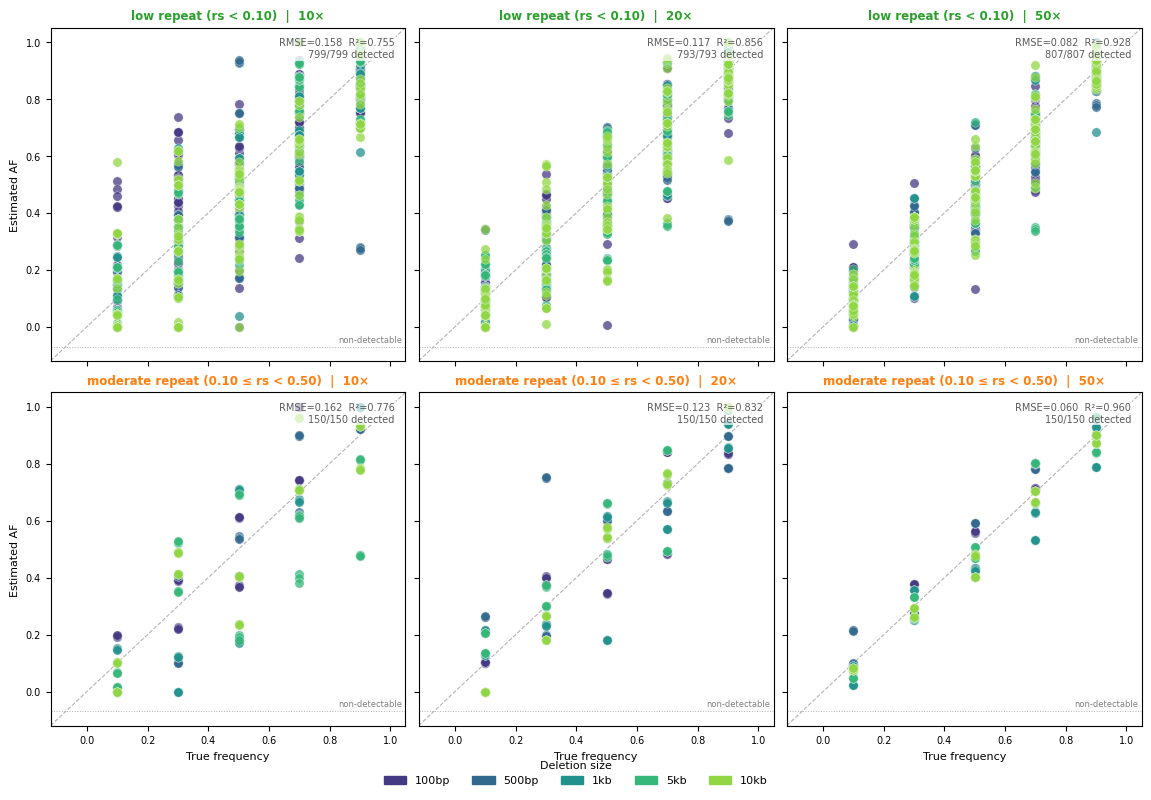

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

# ── Plot: True vs estimated AF — rows=repeat level, cols=coverage ─────────────

SIZE_ORDER   = ['100bp', '500bp', '1kb', '5kb', '10kb']
palette      = sns.color_palette('viridis', len(SIZE_ORDER))
SIZE_COLORS  = dict(zip(SIZE_ORDER, palette))

REGION_ORDER  = ['low repeat', 'moderate repeat', 'high repeat']
REGION_COLORS = {'low repeat': '#2ca02c', 'moderate repeat': '#ff7f0e', 'high repeat': '#d62728'}
REGION_RANGE  = {
    'low repeat':      'rs < 0.10',
    'moderate repeat': '0.10 ≤ rs < 0.50',
    'high repeat':     'rs ≥ 0.50',
}

# Only include region types that have data
active_regions = [r for r in REGION_ORDER
                  if not results_df[results_df['region_type'] == r].empty]

coverages = sorted(results_df['coverage'].unique())
nrows, ncols = len(active_regions), len(coverages)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.8 * nrows),
                         sharex=True, sharey=True, constrained_layout=True)

# Normalise axes to always be 2-D array
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncols == 1:
    axes = axes[:, np.newaxis]

lo, hi = -0.12, 1.05
ND_Y   = -0.07

for i, rtype in enumerate(active_regions):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        sub      = results_df[(results_df['region_type'] == rtype) &
                              (results_df['coverage']    == cov)]
        det_sub  = sub[sub['detected']]
        ndet_sub = sub[~sub['detected']]

        for size in SIZE_ORDER:
            pts = det_sub[det_sub['size'] == size]
            if not pts.empty:
                ax.scatter(pts['freq_nominal'], pts['af_alt'],
                           color=SIZE_COLORS[size], marker='o', s=45, alpha=0.75,
                           edgecolors='white', linewidths=0.3, zorder=3)
            pts = ndet_sub[ndet_sub['size'] == size]
            if not pts.empty:
                ax.scatter(pts['freq_nominal'], [ND_Y] * len(pts),
                           color=SIZE_COLORS[size], marker='o', s=45, alpha=0.75,
                           edgecolors='white', linewidths=0.3, zorder=3)

        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.3, zorder=1)
        ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':', zorder=1)
        ax.text(hi - 0.01, ND_Y + 0.01, 'non-detectable',
                ha='right', va='bottom', fontsize=6, color='0.5')

        n_tot = len(sub); n_det = len(det_sub)
        if n_det >= 2:
            rmse = np.sqrt(((det_sub['af_alt'] - det_sub['freq_nominal']) ** 2).mean())
            r2   = np.corrcoef(det_sub['freq_nominal'], det_sub['af_alt'])[0, 1] ** 2
            ax.text(0.97, 0.97,
                    f'RMSE={rmse:.3f}  R²={r2:.3f}\n{n_det}/{n_tot} detected',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=7, color='0.35',
                    bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f'{rtype} ({REGION_RANGE[rtype]})  |  {cov}×',
                     fontsize=8.5, fontweight='bold', color=REGION_COLORS[rtype])
        if j == 0:
            ax.set_ylabel('Estimated AF', fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel('True frequency', fontsize=8)
        ax.tick_params(labelsize=7)

size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
fig.legend(handles=size_patches, title='Deletion size',
           loc='lower center', ncol=len(SIZE_ORDER),
           fontsize=8, title_fontsize=8,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

import os; os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/rep_true_vs_est_by_region.pdf',
            bbox_inches='tight')
plt.savefig('../plots/rep_true_vs_est_by_region.png',
            bbox_inches='tight', dpi=150)
plt.show()


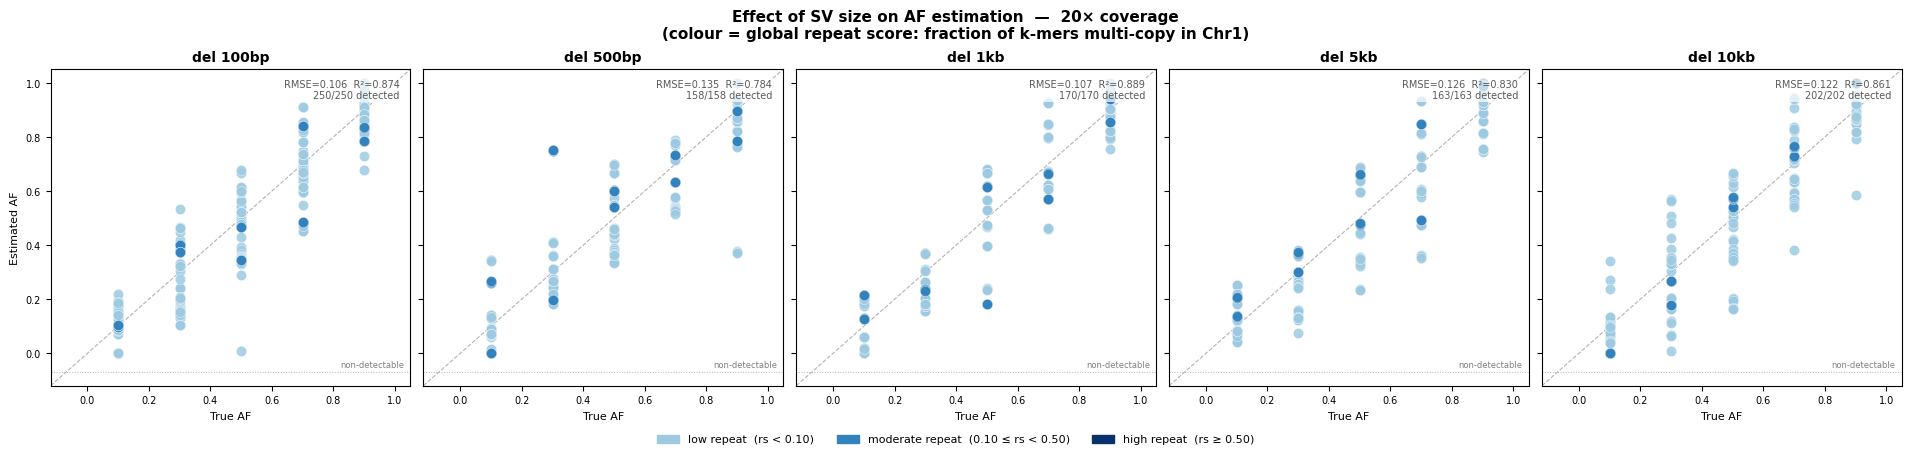

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Plot: Effect of SV size on AF estimation — 20× coverage ──────────────────
#
# One panel per SV size; colour = repeat level (light→dark blue);
# all circles; non-detected at ND_Y band.

TARGET_COV = 20
df = results_df[results_df['coverage'] == TARGET_COV].copy()

REGION_ORDER  = ['low repeat', 'moderate repeat', 'high repeat']
REGION_COLORS = {'low repeat': '#9ecae1', 'moderate repeat': '#3182bd', 'high repeat': '#08306b'}
REGION_RANGE  = {
    'low repeat':      'rs < 0.10',
    'moderate repeat': '0.10 ≤ rs < 0.50',
    'high repeat':     'rs ≥ 0.50',
}
SIZE_ORDER = ['100bp', '500bp', '1kb', '5kb', '10kb']

fig, axes = plt.subplots(1, len(SIZE_ORDER),
                         figsize=(3.8 * len(SIZE_ORDER), 4.2),
                         sharex=True, sharey=True, constrained_layout=True)

lo, hi = -0.12, 1.05
ND_Y   = -0.07

for ax, size in zip(axes, SIZE_ORDER):
    sub  = df[df['size'] == size]
    det  = sub[sub['detected']]
    ndet = sub[~sub['detected']]

    for rg in REGION_ORDER:
        c = REGION_COLORS[rg]
        pts = det[det['region_type'] == rg]
        if not pts.empty:
            ax.scatter(pts['freq_nominal'], pts['af_alt'],
                       color=c, marker='o', s=55, alpha=0.85,
                       edgecolors='white', linewidths=0.3, zorder=3)
        pts = ndet[ndet['region_type'] == rg]
        if not pts.empty:
            ax.scatter(pts['freq_nominal'], [ND_Y] * len(pts),
                       color=c, marker='o', s=55, alpha=0.85,
                       edgecolors='white', linewidths=0.3, zorder=3)

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.3, zorder=1)
    ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':', zorder=1)
    ax.text(hi - 0.02, ND_Y + 0.01, 'non-detectable',
            ha='right', va='bottom', fontsize=6, color='0.5')

    if len(det) >= 2:
        rmse = np.sqrt(((det['af_alt'] - det['freq_nominal']) ** 2).mean())
        r2   = np.corrcoef(det['freq_nominal'], det['af_alt'])[0, 1] ** 2
        n_det, n_tot = len(det), len(sub)
        ax.text(0.97, 0.97,
                f'RMSE={rmse:.3f}  R²={r2:.3f}\n{n_det}/{n_tot} detected',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=7, color='0.35',
                bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f'del {size}', fontsize=10, fontweight='bold')
    ax.set_xlabel('True AF', fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Estimated AF', fontsize=8)

legend_handles = [
    mpatches.Patch(color=REGION_COLORS[rg], label=f'{rg}  ({REGION_RANGE[rg]})')
    for rg in REGION_ORDER
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.07), frameon=False)

fig.suptitle(f'Effect of SV size on AF estimation  —  {TARGET_COV}× coverage\n'
             '(colour = global repeat score: fraction of k-mers multi-copy in Chr1)',
             fontsize=11, fontweight='bold')

plt.savefig('../plots/rep_sv_size_effect_cov20.pdf',
            bbox_inches='tight')
plt.savefig('../plots/rep_sv_size_effect_cov20.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [6]:
results_df = results_df[results_df['rep_id'].isin(['rep1', 'rep2', 'rep3', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8', 'rep9', 'rep10'])]

results_df['k'].value_counts()

k
30    750
31    750
32    750
Name: count, dtype: int64

In [7]:
results_df

,sv_root,sv_type,rep_id,cov_err,coverage,error_rate,size,n_samples,freq_label,freq_nominal,...,af_ref,af_alt,error,abs_error,rel_error,detected,pos_bp,chrom,global_repeat_score,region_type
0,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f10,0.1,...,1.000000,0.000000,-0.100000,0.100000,1.000000,True,3447000,Chr1,0.0000,low repeat
1,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f10,0.1,...,1.000000,0.000000,-0.100000,0.100000,1.000000,True,3447000,Chr1,0.0000,low repeat
2,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f10,0.1,...,1.000000,0.000000,-0.100000,0.100000,1.000000,True,3447000,Chr1,0.0000,low repeat
3,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f30,0.3,...,0.466943,0.533057,0.233057,0.233057,0.776856,True,3447000,Chr1,0.0000,low repeat
4,del,DEL,rep1,cov10_err001,10,0.001,100bp,231,f30,0.3,...,0.467484,0.532516,0.232516,0.232516,0.775052,True,3447000,Chr1,0.0000,low repeat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2844,del,DEL,rep9,cov50_err001,50,0.001,5kb,231,f70,0.7,...,0.320223,0.679778,-0.020222,0.020222,0.028889,True,22373000,Chr1,0.0045,low repeat
2845,del,DEL,rep9,cov50_err001,50,0.001,5kb,231,f70,0.7,...,0.318475,0.681524,-0.018475,0.018475,0.026394,True,22373000,Chr1,0.0045,low repeat
2846,del,DEL,rep9,cov50_err001,50,0.001,5kb,231,f90,0.9,...,0.099672,0.900328,0.000328,0.000328,0.000365,True,22373000,Chr1,0.0045,low repeat
2847,del,DEL,rep9,cov50_err001,50,0.001,5kb,231,f90,0.9,...,0.098936,0.901064,0.001064,0.001064,0.001182,True,22373000,Chr1,0.0045,low repeat


In [ ]:
import re
import pandas as pd
from pathlib import Path

# ── Resolve base path (works locally via mount or directly on cluster) ─────────
for _candidate in [
    Path('/Users/tatiana/Documents_new/visor_freqk'),
    Path('/carnegie/nobackup/scratch/tbellagio/visor_freqk'),
    Path('/home/tbellagio/scratch/visor_freqk'),
]:
    if _candidate.exists():
        BASE = _candidate
        break
else:
    raise FileNotFoundError("Cannot find visor_freqk base directory")

RESULTS_ROOT = BASE / 'results/del'

# ── Full expected grid ─────────────────────────────────────────────────────────
# Edit these to match what you launched.
REP_IDS   = [f'rep{i}' for i in range(1, 31)]
COVERAGES = [10, 20, 50]
SV_FREQS  = [0.10, 0.30, 0.50, 0.70, 0.90]
SIZES     = ['100bp', '500bp', '1kb', '5kb', '10kb']
N_SAMPLES = 231
KS        = [31]   # ← add more k values here if you ran e.g. [30, 31, 32]

from itertools import product
EXPECTED_COLS = ['rep_id', 'coverage', 'freq_nominal', 'n_samples', 'size', 'k']

expected = pd.DataFrame(
    [{'rep_id': r, 'coverage': c, 'freq_nominal': round(f, 2),
      'n_samples': N_SAMPLES, 'size': s, 'k': k}
     for r, c, f, s, k in product(REP_IDS, COVERAGES, SV_FREQS, SIZES, KS)],
    columns=EXPECTED_COLS,
)
print(f"Expected combinations : {len(expected)}")

# ── Compare against results on disk (not results_df — avoids stale cache) ──────
found = set()
for af in RESULTS_ROOT.rglob('*.allele_frequencies.k*.tsv'):
    p = af.relative_to(RESULTS_ROOT).parts
    # path: rep_id / var / cov<X>_err<E> / size / n<N> / f<F> / k<K> / file
    if len(p) != 8 or not p[0].startswith('rep') or p[1] != 'var':
        continue
    mf = re.match(r'f(\d+)', p[5])
    mk = re.match(r'k(\d+)', p[6])
    if not mf or not mk:
        continue
    rep_id        = p[0]
    coverage      = int(p[2].split('_')[0].replace('cov', ''))
    size          = p[3]
    n_samples_val = int(p[4].replace('n', ''))
    freq_nominal  = round(int(mf.group(1)) / 100.0, 2)
    k_val         = int(mk.group(1))
    found.add((rep_id, coverage, freq_nominal, n_samples_val, size, k_val))

found_df = pd.DataFrame(list(found), columns=EXPECTED_COLS)
print(f"Found on disk         : {len(found_df)}")

missing = (
    expected
    .merge(found_df, on=EXPECTED_COLS, how='left', indicator=True)
    .query('_merge == "left_only"')
    .drop(columns='_merge')
    .sort_values(['rep_id', 'coverage', 'freq_nominal', 'size', 'k'])
    .reset_index(drop=True)
)
print(f"Missing               : {len(missing)}")
missing


Expected combinations : 2250


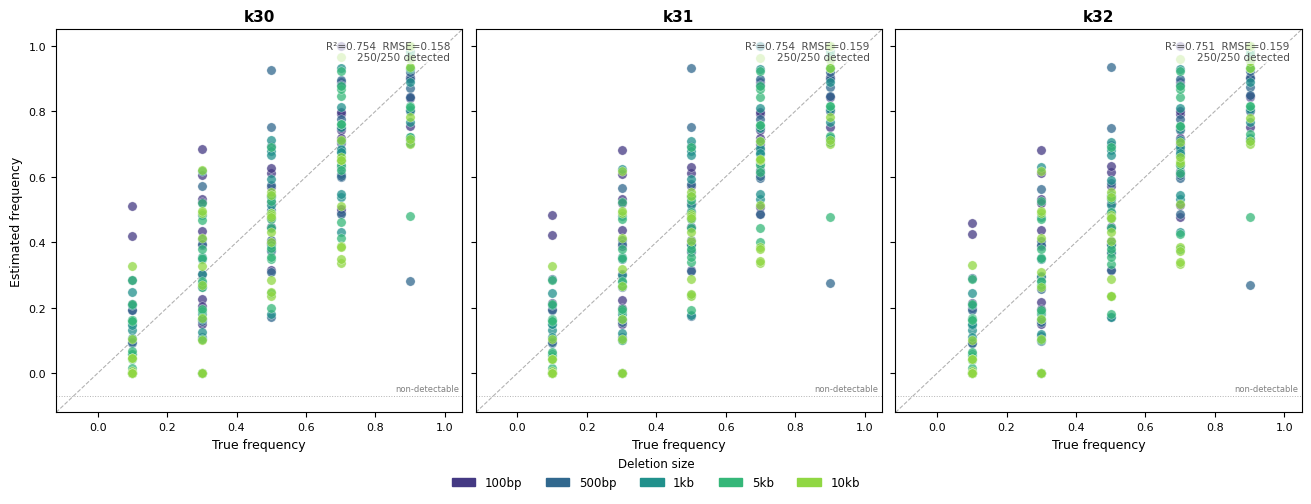

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import pandas as pd

# ── Plot: True vs Estimated AF — coverage 10×, reps 1-10, all SV sizes ────────
# Panels = k-mer levels (k30, k31, k32)

results_df = pd.read_csv('../summaries/results_rep.csv')
results_df['detected'] = results_df['af_alt'].notna()

# Filter: coverage 10x, reps 1–10
REPS_10 = [f'rep{i}' for i in range(1, 11)]
df10 = results_df[
    (results_df['coverage'] == 10) &
    (results_df['rep_id'].isin(REPS_10))
].copy()

KMER_ORDER = ['k30', 'k31', 'k32']
SIZE_ORDER  = ['100bp', '500bp', '1kb', '5kb', '10kb']
palette     = sns.color_palette('viridis', len(SIZE_ORDER))
SIZE_COLORS = dict(zip(SIZE_ORDER, palette))

lo, hi = -0.12, 1.05
ND_Y   = -0.07

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5),
                         sharex=True, sharey=True, constrained_layout=True)

for ax, k in zip(axes, KMER_ORDER):
    sub  = df10[df10['k_label'] == k]
    det  = sub[sub['detected']]
    ndet = sub[~sub['detected']]

    for size in SIZE_ORDER:
        c = SIZE_COLORS[size]
        pts = det[det['size'] == size]
        if not pts.empty:
            ax.scatter(pts['freq_nominal'], pts['af_alt'],
                       color=c, marker='o', s=45, alpha=0.75,
                       edgecolors='white', linewidths=0.3, zorder=3)
        pts_nd = ndet[ndet['size'] == size]
        if not pts_nd.empty:
            ax.scatter(pts_nd['freq_nominal'], [ND_Y] * len(pts_nd),
                       color=c, marker='o', s=45, alpha=0.75,
                       edgecolors='white', linewidths=0.3, zorder=3)

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.3, zorder=1)
    ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':', zorder=1)
    ax.text(hi - 0.01, ND_Y + 0.01, 'non-detectable',
            ha='right', va='bottom', fontsize=6, color='0.5')

    n_tot = len(sub); n_det = len(det)
    if n_det >= 2:
        r2   = np.corrcoef(det['freq_nominal'], det['af_alt'])[0, 1] ** 2
        rmse = np.sqrt(((det['af_alt'] - det['freq_nominal']) ** 2).mean())
        ax.text(0.97, 0.97,
                f'R²={r2:.3f}  RMSE={rmse:.3f}\n{n_det}/{n_tot} detected',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=7.5, color='0.3',
                bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(k, fontsize=11, fontweight='bold')
    ax.set_xlabel('True frequency', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Estimated frequency', fontsize=9)

size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
fig.legend(handles=size_patches, title='Deletion size',
           loc='lower center', ncol=len(SIZE_ORDER),
           fontsize=8.5, title_fontsize=8.5,
           bbox_to_anchor=(0.5, -0.1), frameon=False)


import os; os.makedirs('../summaries/plots', exist_ok=True)
plt.savefig('../summaries/plots/rep_cov10_kmer_comparison.pdf', bbox_inches='tight')
plt.savefig('../summaries/plots/rep_cov10_kmer_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
results_df['global_repeat_score'].describe()

count    2849.000000
mean        0.027201
std         0.054300
min         0.000000
25%         0.000000
50%         0.000800
75%         0.007000
max         0.175400
Name: global_repeat_score, dtype: float64

In [ ]:
# ── Method comparison: freqk vs vg giraffe ─────────────────────────────────────
# Scatter of estimated AF vs nominal (true) AF, one panel per method.  Prints
# R^2 (coefficient of determination) per method, using only detections.
import matplotlib.pyplot as plt
import numpy as np

METHODS = [("freqk", "af_alt", "#1f77b4"),
           ("vg giraffe", "af_alt_vg_giraffe", "#d62728")]
METHODS = [m for m in METHODS if m[1] in results_df.columns]

if len(METHODS) < 2:
    print("vg_giraffe column not in results_df yet — run 05b to produce it.")
else:
    fig, axes = plt.subplots(1, len(METHODS),
                             figsize=(4.2 * len(METHODS), 4.2),
                             sharex=True, sharey=True)
    if len(METHODS) == 1:
        axes = [axes]

    lo, hi = -0.05, 1.05
    for ax, (label, col, color) in zip(axes, METHODS):
        sub = results_df[["freq_nominal", col]].dropna()
        x = sub["freq_nominal"].to_numpy()
        y = sub[col].to_numpy()
        ax.scatter(x, y, s=18, alpha=0.55, color=color, edgecolor="none")
        ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=0.8)

        # R^2 (coefficient of determination)
        if len(x) >= 2:
            ss_res = np.sum((y - x) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
            mae = np.mean(np.abs(y - x))
            ax.text(0.02, 0.95,
                    f"n = {len(x)}\nR² = {r2:.3f}\nMAE = {mae:.3f}",
                    transform=ax.transAxes, va="top", fontsize=10,
                    bbox=dict(boxstyle="round", fc="white", alpha=0.8))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel("true AF")
        ax.set_title(label)
        ax.set_aspect("equal")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("estimated AF")
    fig.suptitle("freqk vs vg giraffe — all replicates, sizes, coverages", y=1.02)
    plt.tight_layout()
    plt.show()

    # Per-method R² split by coverage and size
    import pandas as pd
    summary_rows = []
    for label, col, _ in METHODS:
        for (cov, sz), grp in results_df.dropna(subset=[col]).groupby(["coverage", "size"]):
            y = grp[col].to_numpy()
            x = grp["freq_nominal"].to_numpy()
            if len(x) < 2:
                continue
            ss_res = np.sum((y - x) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
            summary_rows.append({"method": label, "coverage": cov, "size": sz,
                                 "n": len(x), "R2": r2,
                                 "MAE": np.mean(np.abs(y - x))})
    if summary_rows:
        print("\nR² per (method, coverage, size):")
        print(pd.DataFrame(summary_rows).round(3).to_string(index=False))